Graph loaded with 761 nodes and 1029 edges
Total Girvan-Newman iterations: 760

Communities at iteration 0 (2 groups):
({0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 105, 106, 107, 108, 109, 110, 111, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 191, 193, 194, 195, 196, 197, 198, 199, 201, 202, 203, 204, 205, 207, 208, 209

<Figure size 1200x600 with 0 Axes>

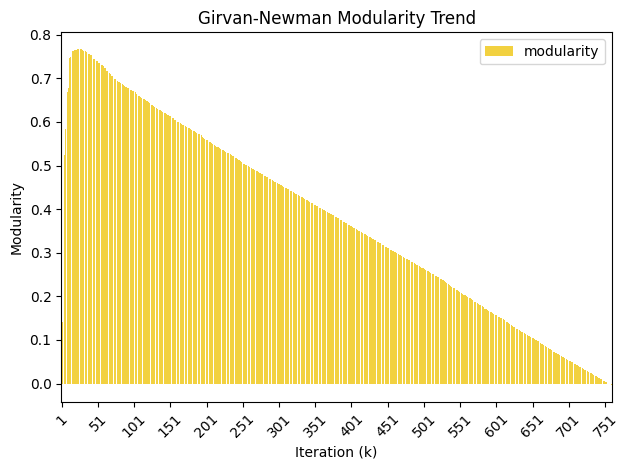

In [ ]:
# Step 1: Upload dataset, Import code (starting point), and update all necessary imports.

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
from networkx.algorithms.community import modularity


# Step 2: Load the dataset
matrix = mmread('rt-twitter-copen.mtx')
G = nx.from_scipy_sparse_array(matrix)
print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Step 3: Find communities using Girvan-Newman and store modularity
communities_gn = list(nx.community.girvan_newman(G))

# Create modularity dataframe
modularity_df = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(G, communities_gn[k])]
        for k in range(len(communities_gn))
    ],
    columns=["k", "modularity"],
)

# Step 4: Print key Girvan-Newman iterations
print(f"Total Girvan-Newman iterations: {len(communities_gn)}")

print("\nCommunities at iteration 0 (2 groups):")
print(communities_gn[0])  # First split

if len(communities_gn) > 20:
    print("\nCommunities at iteration 20:")
    print(communities_gn[20])  # Intermediate
else:
    print("\n(Graph too small for iteration 20)")

print("\nFinal communities:")
print(communities_gn[-1])  # Final state

# Step 5: modularity plot
plt.figure(figsize=(12, 6))  # Wider figure
ax = modularity_df.plot.bar(
    x="k",
    y="modularity",
    color="#F2D140",
    title="Girvan-Newman Modularity Trend",
    width=0.8,  # Thinner bars
)

# Customize x-axis to show every N-th iteration
N = 50  # Show every 50th iteration
ax.set_xticks(range(0, len(modularity_df), N))
ax.set_xticklabels(modularity_df["k"][::N], rotation=45)

plt.xlabel("Iteration (k)")
plt.ylabel("Modularity")
plt.tight_layout()  # Prevent label cutoff
plt.show()


### Observations for Step 4:

The algorithm ran for **760 iterations** (equal to the number of nodes minus 1), terminating when no edges were left. At each step, it removed the edge with the highest betweenness centrality, hierarchically splitting the network into smaller communities until every node became its own community (singleton).  


### Observations for Step 5:

- The highest modularity occurs early (e.g., `k=1`), indicating the optimal split into meaningful communities.  
- Modularity drops as GN continues splitting, creating the small groups (singletons). This tells us GN's hierarchical nature—it maximizes modularity temporarily but doesn't stop at the global optimum.  

Why? This is because GN is a divisive algorithm; it doesn't optimize modularity directly but removes edges based on betweenness, leading to eventual fragmentation; hence why modularity decreases as iterations go up.

In [ ]:
from networkx.algorithms.community import louvain_communities

# Step 6: Louvain execution with intermediate steps
communities_louvain = []

# 1. Convert to undirected graph (Louvain requirement)
G_undir = G.to_undirected()

# 2. Run first level
try:
    level_0 = louvain_communities(G_undir, resolution=1, seed=42)
    communities_louvain.append(level_0)

    # 3. Run subsequent levels until convergence
    for level in range(1, 10):  # Max 10 levels (usually converges in 2-3)
        current_comm = louvain_communities(G_undir, resolution=1, seed=42, max_level=level)

        # Stop if no change from previous level
        if current_comm == communities_louvain[-1]:
            break

        communities_louvain.append(current_comm)

except Exception as e:
    print(f"Error: {e}")
    # Fallback: Use single-level Louvain if dendrogram fails
    communities_louvain = [louvain_communities(G_undir, resolution=1)]

# Results
print(f"Louvain iterations completed: {len(communities_louvain)}")
if len(communities_louvain) > 0:
    print(f"Final number of communities: {len(communities_louvain[-1])}")
    print(f"Sample communities: {list(communities_louvain[-1])[:2]}")  # Show first 2
else:
    print("No communities detected - check graph connectivity.")

Louvain iterations completed: 5
Final number of communities: 21
Sample communities: [{512, 257, 384, 3, 642, 518, 134, 9, 650, 526, 143, 661, 534, 151, 667, 28, 284, 541, 35, 424, 42, 684, 686, 175, 48, 561, 691, 564, 440, 315, 571, 187, 574, 702, 576, 579, 72, 717, 463, 80, 594, 722, 467, 468, 212, 345, 219, 92, 93, 479, 736, 227, 742, 232, 105, 361, 617, 748, 238, 498, 247, 511}, {117, 646, 214, 281, 665, 698}]


### Observations for Step 7:

Louvain Algorithm Iterations:

- Completed in 5 iterations (length of communities_louvain).

Girvan-Newman Algorithm Iterations:

- Completed in 760 iterations (length of communities_gn).



In [ ]:
# Step 8: Print all Louvain steps
print(f"\nLouvain Algorithm: {len(communities_louvain)} Levels")
print("=" * 50)

for level, comm in enumerate(communities_louvain):
    print(f"\nLEVEL {level}")
    print(f"• Modularity: {modularity(G_undir, comm):.6f}")
    print(f"• Number of communities: {len(comm)}")

    # Print full communities for Level 0 for better visual
    if level == 0:
        print("\nAll Communities:")
        for i, c in enumerate(sorted(comm, key=len, reverse=True)):
            print(f"  {i+1}: {sorted(c)}")
    else:
        # Sample for other levels
        print("\nSample Communities (largest 3):")
        for i, c in enumerate(sorted(comm, key=len, reverse=True)[:3]):
            print(f"  {i+1}: Size {len(c)}, Nodes: {sorted(c)[:5]}...")

    print("-" * 50)


Louvain Algorithm: 5 Levels

LEVEL 0
• Modularity: 0.770332
• Number of communities: 21

All Communities:
  1: [1, 17, 44, 50, 62, 66, 74, 76, 90, 95, 107, 123, 128, 140, 153, 157, 179, 180, 186, 201, 208, 217, 240, 241, 242, 252, 254, 258, 285, 298, 301, 302, 309, 325, 328, 335, 339, 346, 350, 352, 353, 357, 366, 367, 369, 378, 401, 415, 452, 454, 465, 478, 507, 510, 515, 542, 546, 565, 566, 567, 589, 593, 606, 619, 624, 636, 637, 668, 672, 688, 724, 727, 734, 753, 754, 755]
  2: [3, 9, 28, 35, 42, 48, 72, 80, 92, 93, 105, 134, 143, 151, 175, 187, 212, 219, 227, 232, 238, 247, 257, 284, 315, 345, 361, 384, 424, 440, 463, 467, 468, 479, 498, 511, 512, 518, 526, 534, 541, 561, 564, 571, 574, 576, 579, 594, 617, 642, 650, 661, 667, 684, 686, 691, 702, 717, 722, 736, 742, 748]
  3: [2, 29, 34, 36, 38, 40, 70, 73, 79, 97, 130, 136, 137, 163, 193, 195, 218, 220, 246, 248, 263, 267, 274, 303, 313, 340, 341, 364, 397, 402, 404, 409, 411, 429, 436, 441, 442, 448, 471, 519, 520, 538, 548, 553,

In [ ]:
# Step 9: Print modularity at each Louvain level
print("Louvain Modularity Progression:")
print("-" * 30)
for level, comm in enumerate(communities_louvain):
    mod = modularity(G_undir, comm)
    print(f"Level {level}: Modularity = {mod:.6f} (Communities: {len(comm)})")

Louvain Modularity Progression:
------------------------------
Level 0: Modularity = 0.770332 (Communities: 21)
Level 1: Modularity = 0.537055 (Communities: 218)
Level 2: Modularity = 0.744160 (Communities: 55)
Level 3: Modularity = 0.769526 (Communities: 23)
Level 4: Modularity = 0.770332 (Communities: 21)


### Observations for Step 10:

#### Modularity Trends of Both
| Algorithm       | Behavior                     | Peak Modularity | Final Modularity |
|-----------------|------------------------------|-----------------|------------------|
| **Louvain**     | Dip at Level 1, then recovers | 0.770           | 0.770            |
| **GN**          | Peaks early, then declines    | 0.770           | ~0               |

- Both peak at 0.770, but Louvain preserves it while GN destroys communities.

##### To Clarify:

1. **Louvain** is clearly faster (5 iterations), preserves modularity, and yields interpretable communities.

- Why is there so few? I think this is because Louvain uses greedy aggregation and merges nodes in coarse-grained phases, converging quickly.

2. **Girvan-Newman** is clearly slower (760 iterations), destroys communities, and is mainly useful for hierarchical analysis.  

- Why is there so many? I think this is because GN removes edges one-by-one until all nodes are isolated, requiring *m-n+2* steps (where *m* = edges, *n* = nodes).

